# **Data Normalization Techniques**


Here, we will focus on data normalization. This includes identifying compensation-related columns, applying normalization techniques, and visualizing the data distributions.


## Objectives


- Identify duplicate rows and remove them.

- Check and handle missing values in key columns.

- Identify and normalize compensation-related columns.

- Visualize the effect of normalization techniques on data distributions.


-----


## Hands on Lab


#### Step 1: Install and Import Libraries


In [1]:
!pip install pandas

In [2]:
!pip install matplotlib

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### Step 2: Load the Dataset into a DataFrame


In [2]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)

# Display the first few rows to check if data is loaded correctly
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Section 1: Handling Duplicates
##### Identify and remove duplicate rows.


In [3]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [9]:
df.drop_duplicates(inplace=True)

# Check how many rows were removed
print("Number of duplicate rows after removal:", df.duplicated().sum())


Number of duplicates removed: 0


### Section 2: Handling Missing Values
##### Identify missing values in `CodingActivities`.


In [4]:
# Check missing values by column
missing_values = df['CodingActivities'].isnull().sum()
print("Missing values per column:\n", missing_values)


Missing values per column:
 10971


##### Impute missing values in CodingActivities with forward-fill.


In [5]:
# Impute missing values with forward-fill
df['CodingActivities'] = df['CodingActivities'].ffill()
# Verify missing values after
print("Missing after ffill:", df['CodingActivities'].isnull().sum())



Missing after ffill: 0


**Note**: Before normalizing `ConvertedCompYearly`, ensure that missing values are handled appropriately. Here, rows with missing compensation values are dropped so that the normalization calculations use valid numerical values only.


### Section 3: Normalizing Compensation Data
##### Identify compensation-related columns, such as ConvertedCompYearly.
Normalization is commonly applied to compensation data to bring values within a comparable range. Here, you’ll identify ConvertedCompYearly or similar columns, which contain compensation information. This column will be used in the subsequent tasks for normalization.


**Column Name:** `ConvertedCompYearly`

**Description:** Annual compensation (salary + bonuses + perks), already expressed on an annual basis.

In [6]:
# Check missing values in ConvertedCompYearly
print("Missing ConvertedCompYearly values before handling:", df['ConvertedCompYearly'].isnull().sum())

# Drop rows where ConvertedCompYearly is missing
df = df.dropna(subset=['ConvertedCompYearly']).copy()

# Verify that no missing values remain
print("Missing ConvertedCompYearly values after handling:", df['ConvertedCompYearly'].isnull().sum())


Missing ConvertedCompYearly values before handling: 42002
Missing ConvertedCompYearly values after handling: 0


##### Normalize ConvertedCompYearly using Min-Max Scaling.
Min-Max Scaling brings all values in a column to a 0-1 range, making it useful for comparing data across different scales. Here, you will apply Min-Max normalization to the ConvertedCompYearly column, creating a new column ConvertedCompYearly_MinMax with normalized values.


In [7]:
# Min-Max normalization
df['ConvertedCompYearly_MinMax'] = (df['ConvertedCompYearly'] - df['ConvertedCompYearly'].min()) / \
                                   (df['ConvertedCompYearly'].max() - df['ConvertedCompYearly'].min())

# Show the first few normalized values
df[['ConvertedCompYearly', 'ConvertedCompYearly_MinMax']].head()


,ConvertedCompYearly,ConvertedCompYearly_MinMax
72,7322.0,0.000450
374,30074.0,0.001850
379,91295.0,0.005616
385,53703.0,0.003303
389,110000.0,0.006766


##### Apply Z-score Normalization to `ConvertedCompYearly`.

Z-score normalization standardizes values by converting them to a distribution with a mean of 0 and a standard deviation of 1. This method is helpful for datasets with a Gaussian (normal) distribution. Here, you’ll calculate Z-scores for the ConvertedCompYearly column, saving the results in a new column ConvertedCompYearly_Zscore.


In [8]:
# Calculate mean and standard deviation of ConvertedCompYearly
mean_cc = df['ConvertedCompYearly'].mean()
std_cc = df['ConvertedCompYearly'].std()

# Apply Z‑score normalization
df['ConvertedCompYearly_Zscore'] = (df['ConvertedCompYearly'] - mean_cc) / std_cc

# Display some entries to check
df[['ConvertedCompYearly', 'ConvertedCompYearly_Zscore']].head(10)


,ConvertedCompYearly,ConvertedCompYearly_Zscore
72,7322.0,-0.422117
374,30074.0,-0.300290
379,91295.0,0.027521
385,53703.0,-0.173767
389,110000.0,0.127678
392,161044.0,0.400996
395,121018.0,0.186674
398,195000.0,0.582815
403,44586.0,-0.222585
409,57999.0,-0.150764


##### Visualize the distribution of `ConvertedCompYearly`, `ConvertedCompYearly_MinMax`, and `ConvertedCompYearly_Zscore`

Visualization helps you understand how normalization changes the data distribution. Create histograms for the original `ConvertedCompYearly` and its normalized versions.

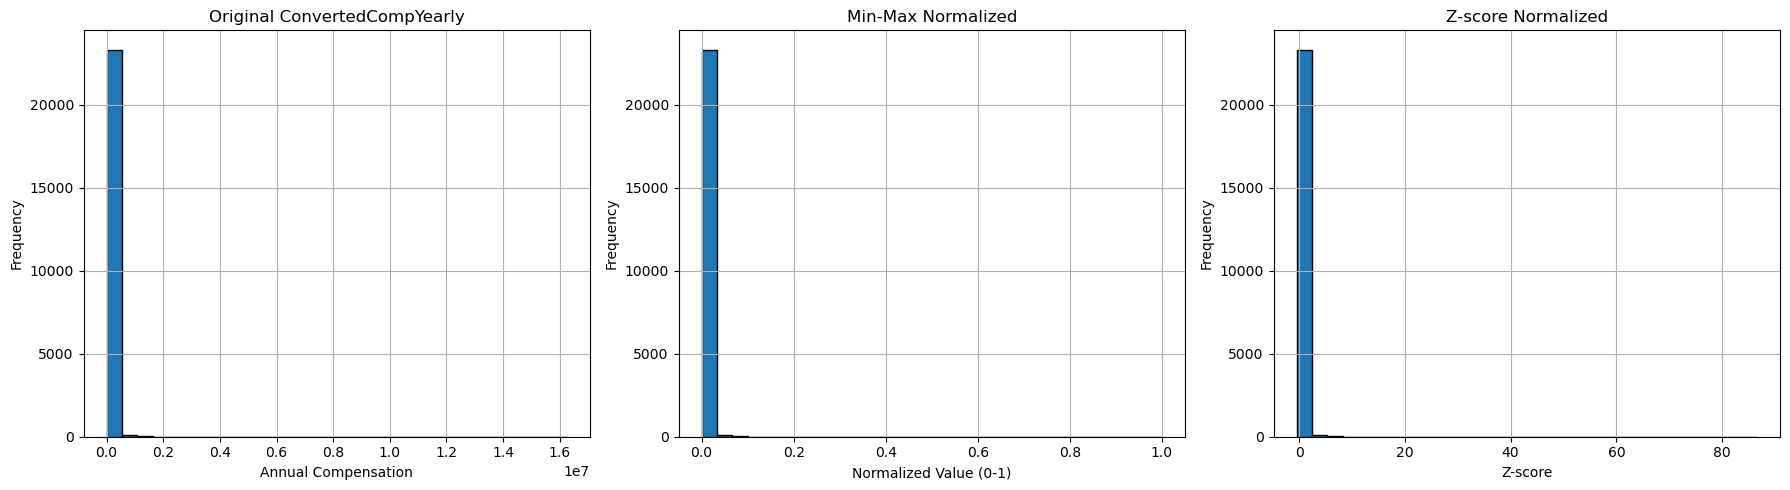

In [10]:
# Visualize the original and normalized compensation distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original
df['ConvertedCompYearly'].hist(ax=axes[0], bins=30, edgecolor='black')
axes[0].set_title('Original ConvertedCompYearly')
axes[0].set_xlabel('Annual Compensation')
axes[0].set_ylabel('Frequency')

# Min-Max Normalized
df['ConvertedCompYearly_MinMax'].hist(ax=axes[1], bins=30, edgecolor='black')
axes[1].set_title('Min-Max Normalized')
axes[1].set_xlabel('Normalized Value (0-1)')
axes[1].set_ylabel('Frequency')

# Z-score Normalized
df['ConvertedCompYearly_Zscore'].hist(ax=axes[2], bins=30, edgecolor='black')
axes[2].set_title('Z-score Normalized')
axes[2].set_xlabel('Z-score')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


### Summary


- Identifying and removing duplicate rows.
- Checking and imputing missing values in `CodingActivities`.
- Handling missing values in `ConvertedCompYearly` before normalization.
- Applying Min-Max scaling and Z-score normalization to compensation data.
- Visualizing the original and normalized compensation distributions.